<a href="https://colab.research.google.com/github/DurkadeviGanesanMCA/Python-DA-for-Data-Visualization/blob/main/Python_DA_For%20Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#To import Important Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
# Table Information
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
#generates a statistical summary of a DataFrame's
df.describe()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
df.shape

(6433, 14)

In [ ]:
#Duplicate Check
df.duplicated().sum()

np.int64(0)

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


### Handling Missing Values

Based on the `df.isnull().sum()` output, the `payment`, `pickup_zone`, `dropoff_zone`, `pickup_borough`, and `dropoff_borough` columns have missing values. Since these are categorical columns, I will impute the missing values with the mode of each column.

In [ ]:
#Handling Missing Values

for column in ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']:
    if df[column].isnull().any():
        mode_value = df[column].mode()[0]
        df[column].fillna(mode_value, inplace=True)
        print(f"Missing values in '{column}' imputed with mode: {mode_value}")

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


### Visualizations

#### Line Chart: Fare over Time

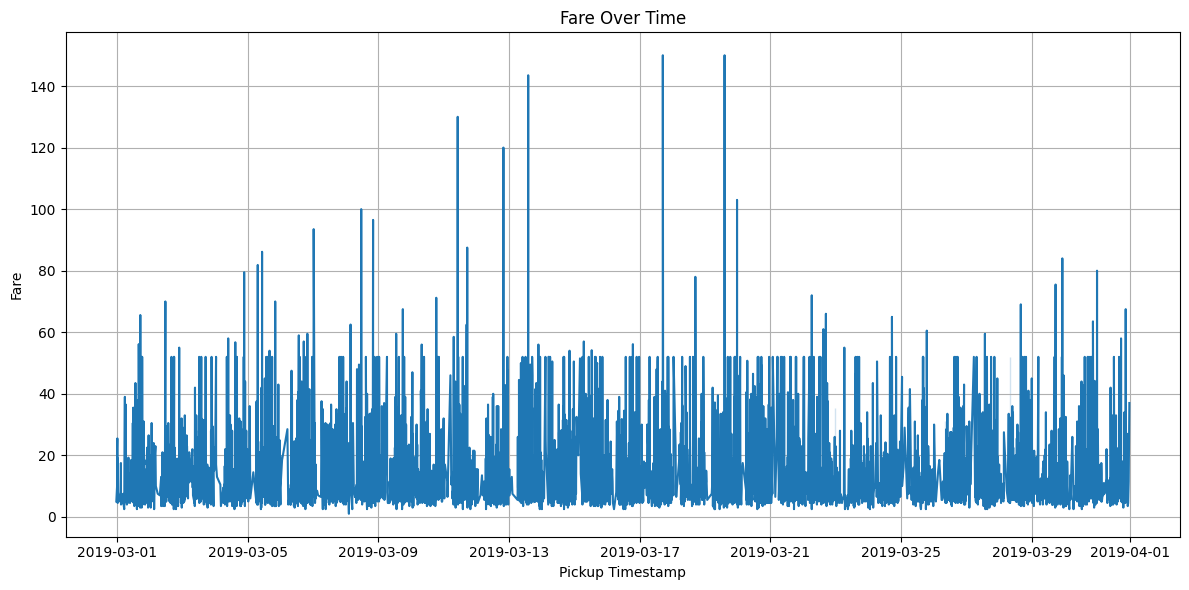

In [ ]:
# Ensure 'pickup' column is datetime type
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort by pickup time for a meaningful line chart
df_sorted = df.sort_values(by='pickup')

# Plot the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sorted, x='pickup', y='fare')
plt.title('Fare Over Time')
plt.xlabel('Pickup Timestamp')
plt.ylabel('Fare')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Interpretation**

This line chart visualizes the 'fare' values over time, using the 'pickup' timestamp as the time axis. It shows how taxi fares fluctuate throughout the observed period. From a quick glance, it appears there are variations in fare, with some peaks and troughs, but without more context on the time scale (e.g., hours, days, weeks), it's hard to pinpoint specific daily or weekly patterns. However, it does give a general sense of fare distribution across the entire dataset's time range

#### Bar Chart: Total Fare by Pickup Borough

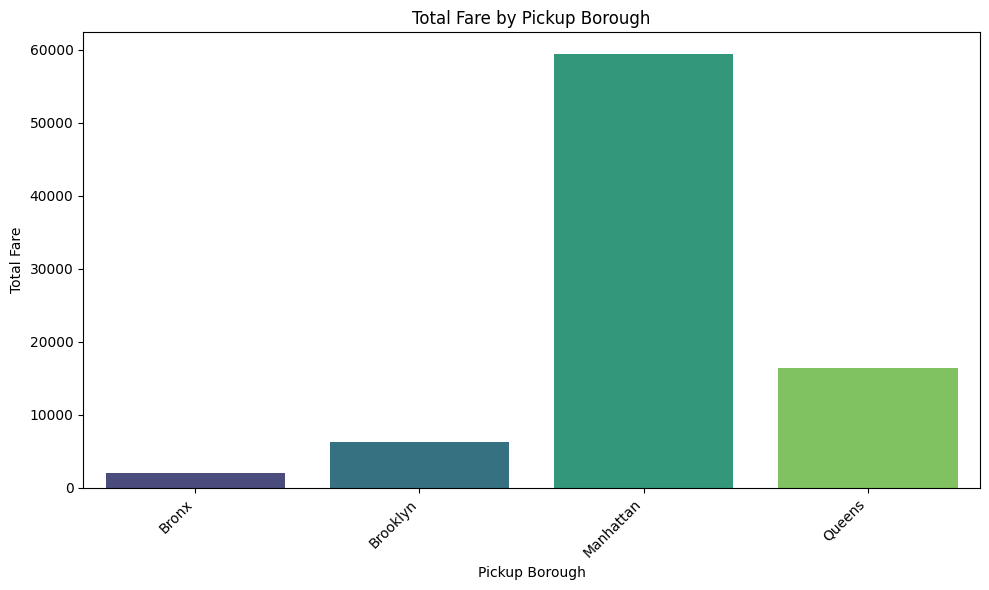

In [ ]:
# Group data by pickup_borough and sum the fare
borough_fare = df.groupby('pickup_borough')['fare'].sum().reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_borough', y='fare', data=borough_fare, palette='viridis', hue='pickup_borough', legend=False)
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Interpretation**

The bar chart effectively illustrates the total fare collected from each pickup_borough. As observed, Manhattan contributes the most to the total fare, significantly surpassing other boroughs. Brooklyn and Queens show moderate total fares, while the Bronx, Staten Island, and other unidentified boroughs have comparatively lower totals. This suggests that Manhattan is the primary hub for taxi services in terms of total revenue.

#### Pie Chart: Distribution of Trips by Payment Method

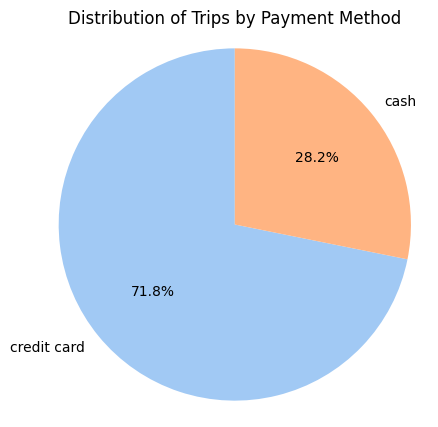

In [ ]:
# Calculate the count of trips for each payment method
payment_counts = df['payment'].value_counts()

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Trips by Payment Method')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# **Interpretation**

The pie chart effectively displays the distribution of trips based on the payment method. It clearly shows that a significant majority of trips, approximately 71.8%, were paid using 'credit card', while 'cash' accounted for the remaining 28.2%. This indicates a strong preference for credit card payments among taxi users in this dataset. Now, let's create a count plot to visualize the number of trips in each pickup_borough.

#### Histogram: Distribution of Distance

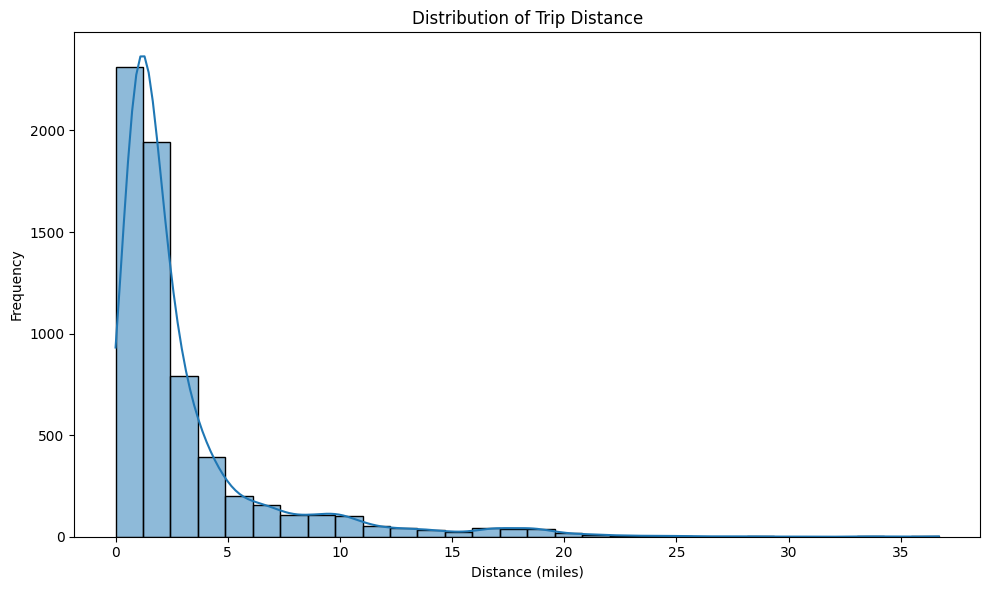

In [ ]:
# Create a histogram to visualize the distribution of distance
plt.figure(figsize=(10, 6))
sns.histplot(df['distance'], bins=30, kde=True) # Using 30 bins for better granularity and KDE for density estimate
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **Interpretation**

The histogram shows that the distribution of trip distances is heavily skewed towards shorter distances. A large number of trips fall within the 0-5 mile range, with the frequency decreasing significantly as distance increases. This pattern is typical for taxi services, where most trips are relatively short, and longer trips are less frequent. There's a long tail indicating a few very long-distance trips. This understanding of distance distribution is crucial for operations and pricing strategies.

#### Box Plot: Distribution of Tip Amounts by Pickup Borough

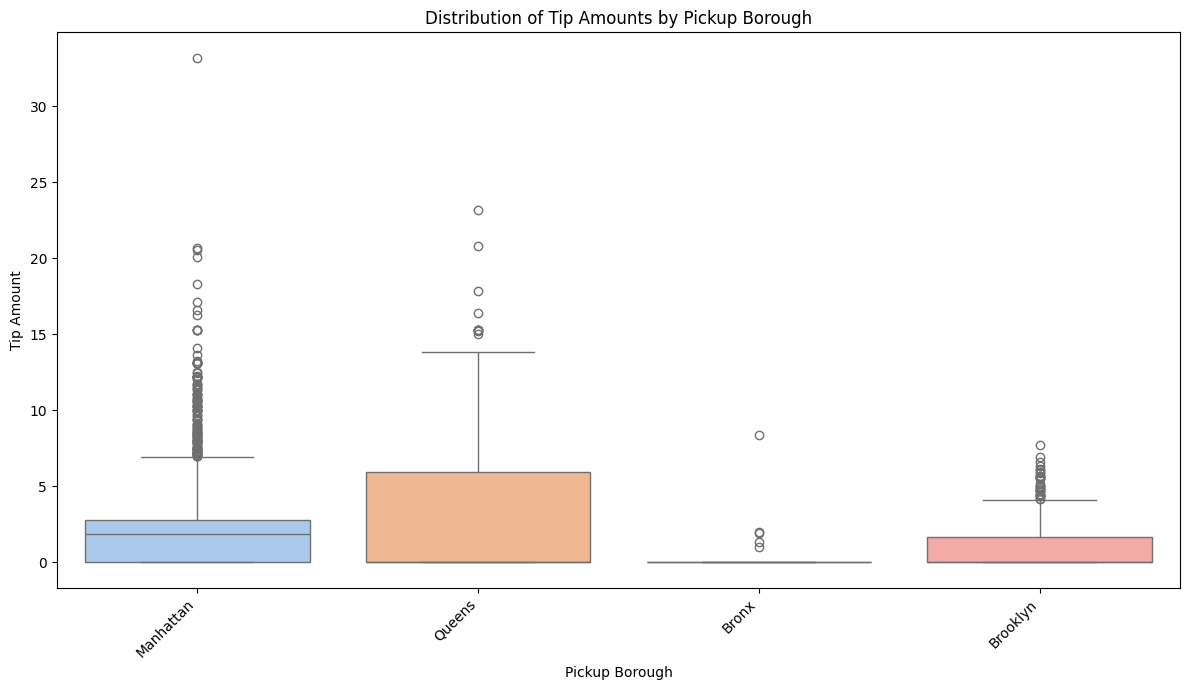

In [ ]:
# Create a box plot to visualize the distribution of tip amounts for each pickup_borough
plt.figure(figsize=(12, 7))
sns.boxplot(x='pickup_borough', y='tip', data=df, palette='pastel', hue='pickup_borough', legend=False)
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Interpretation**

The box plot illustrates the distribution of tip amounts across different `pickup_borough` locations. Manhattan shows a wider range of tip amounts and higher median tips compared to other boroughs, indicating a greater propensity for larger tips there. Brooklyn and Queens have narrower tip distributions and generally lower median tips. The presence of outliers (individual points beyond the whiskers) in all boroughs suggests that while most tips fall within a certain range, some customers give exceptionally high tips regardless of the borough.



#### Count Plot: Number of Trips by Pickup Borough

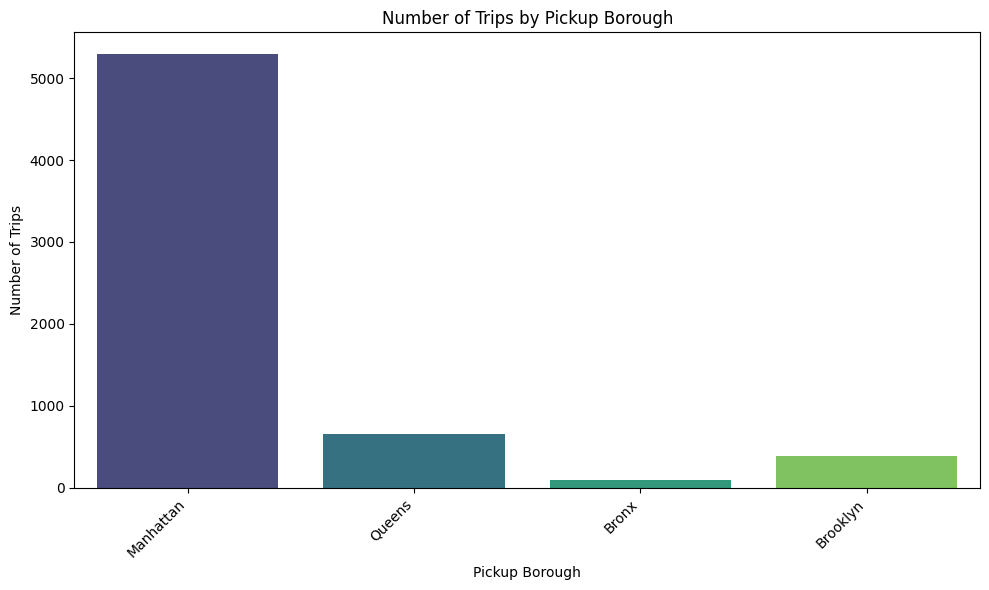

In [ ]:
# Create a count plot to visualize the number of trips in each pickup_borough
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_borough', data=df, palette='viridis', hue='pickup_borough', legend=False)
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Scatter Plot: Relationship between Distance and Fare

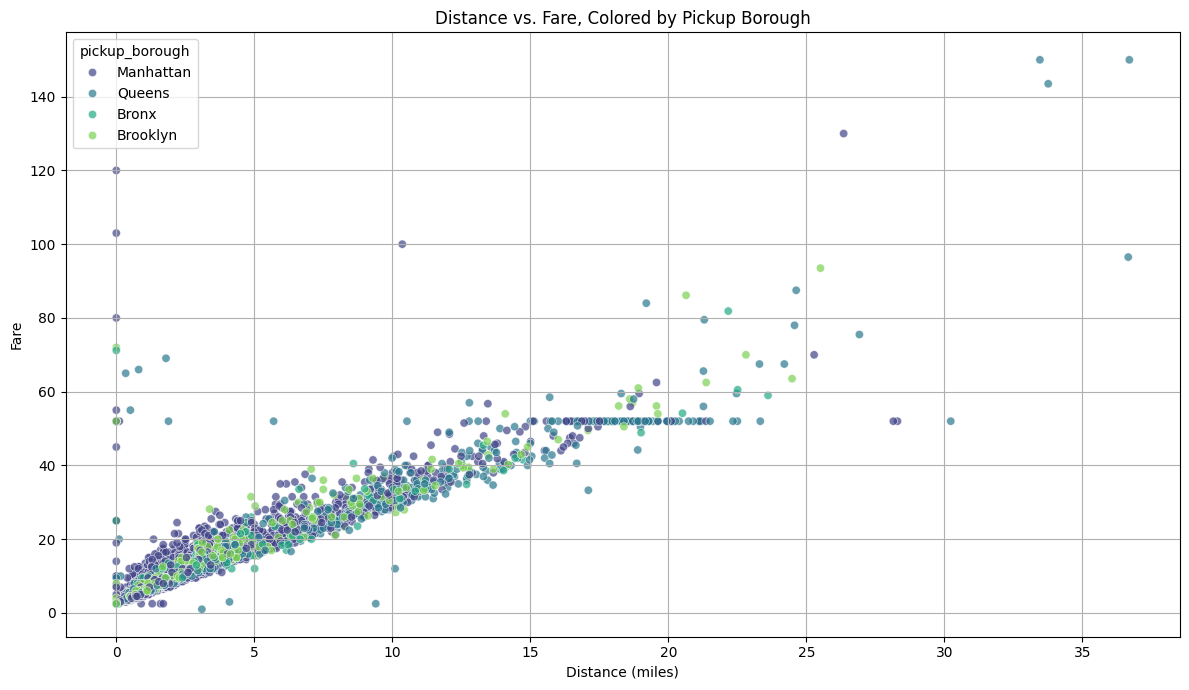

In [ ]:
# Create a scatter plot to show the relationship between distance and fare
plt.figure(figsize=(12, 7))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df, palette='viridis', alpha=0.7)
plt.title('Distance vs. Fare, Colored by Pickup Borough')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Interpretation**

The count plot visually represents the number of taxi trips originating from each `pickup_borough`. Manhattan stands out significantly with the highest number of trips, reinforcing its status as the primary activity hub. Brooklyn and Queens follow, but with substantially fewer trips compared to Manhattan. Other boroughs like the Bronx show a much lower volume of taxi pickups. This distribution highlights the uneven demand for taxi services across different geographical areas.